In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import calendar
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression


In [139]:
sns.color_palette('husl',10)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8616090647292522, 0.536495730113334, 0.19548899031476086),
 (0.6804189127793346, 0.6151497514677574, 0.19405452111445337),
 (0.46810256823426105, 0.6699492535792404, 0.1928958739904499),
 (0.20125317221201128, 0.6907920815379025, 0.47966761189275336),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.2197995660828324, 0.6625157876850336, 0.7732093159317209),
 (0.433280341176423, 0.6065273407962815, 0.9585467098271748),
 (0.8004936186423958, 0.47703363533737203, 0.9579547196007522),
 (0.962272393509669, 0.3976451968965351, 0.8008274363432775)]

In [140]:
sns.set_style('darkgrid')
sns.set_palette('husl')

In [141]:
df = pd.read_csv('../datasets/global_hantavirus_surveillance_dataset_2026.csv', delimiter=',', encoding='utf-8')
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


## Главные вопросы исследования:
- Кто в зоне риска? (возраст/пол/регион с самой высокой летальностью)

- Какие симптомы наиболее опасны? (корреляция с летальностью)

- Как зависит тяжесть от типа передачи? (Rodent-to-Human vs другие)

- Различаются ли штаммы по симптомам/летальности?

- Нужна ли госпитализация? (факторы, влияющие на hospital=1)

- Есть ли сезонность? (влияние report_date)

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   str    
 1   country                2000 non-null   str    
 2   region                 2000 non-null   str    
 3   report_date            2000 non-null   str    
 4   virus_strain           2000 non-null   str    
 5   transmission_type      2000 non-null   str    
 6   exposure_source        2000 non-null   str    
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   str    
 9   symptoms               2000 non-null   str    
 10  hospitalization        2000 non-null   str    
 11  fatality               2000 non-null   str    
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rodent_presence

сначала сделаем преобразование некоторых колонок для удобства подсчета

In [143]:
df['fatality'] = df['fatality'].map({'Yes':1, 'No':0}).astype('int64')

In [144]:
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce', dayfirst=True)

In [145]:
df['hospitalization'] = df['hospitalization'].map({'Yes':1, 'No':0}).astype('int64')

In [146]:
df['report_date'].value_counts()[df['report_date'].value_counts() >= 8].size / df['report_date'].nunique()

0.07142857142857142

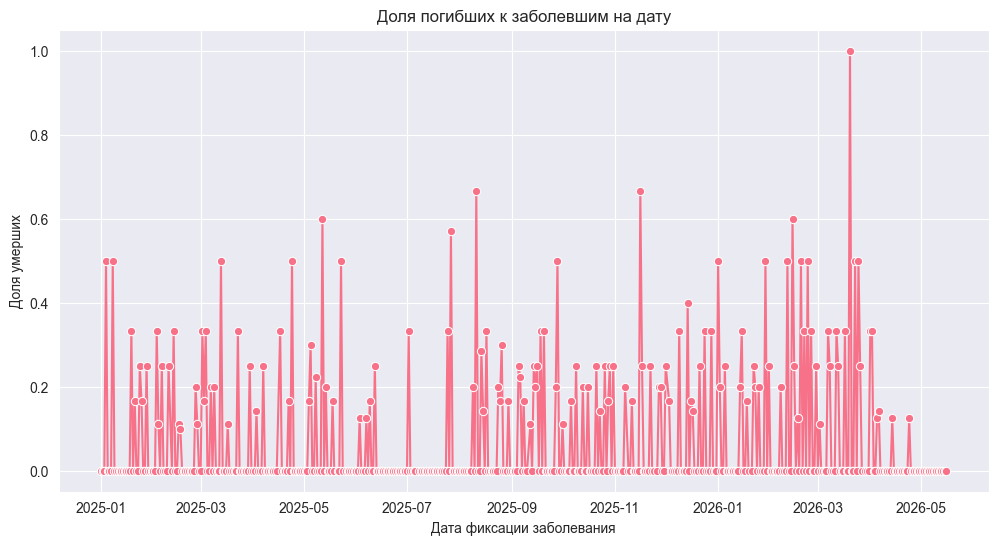

In [147]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='report_date', y='fatality', errorbar=None, marker='o')
plt.title('Доля погибших к заболевшим на дату')
plt.ylabel('Доля умерших')
plt.xlabel('Дата фиксации заболевания')

plt.show()

In [148]:
fatality_table = round(pd.crosstab(df['report_date'], df['fatality'], normalize='index')*100,2).sort_values(by=1, ascending=False)
print(f'Количество дней со смертностью от 50 до 100%: {fatality_table[fatality_table[1] > 50][1].size}') # количество вспышек, когда доля умерших более 50%
fatality_count = df['fatality'].sum()
print(f'Общее число умерших: {fatality_count}, что составляет {round(fatality_count/df.shape[0]*100,2)} % от общего числа заболевших')
print(f'Доля "вспышек" с высокой смертностью от общего числа дней со смертями:\
    {round(fatality_table[fatality_table[1] > 50][1].size / fatality_table.shape[0]*100,2)} %')

Количество дней со смертностью от 50 до 100%: 6
Общее число умерших: 155, что составляет 7.75 % от общего числа заболевших
Доля "вспышек" с высокой смертностью от общего числа дней со смертями:    1.22 %


Общая летальность хантавируса в исследуемой выборке составляет 7.75%. Случаи с экстремально высокой летальностью (>50% умерших в день) чрезвычайно редки и наблюдались лишь в 1.22% дней с зарегистрированными случаями (6 дней из 490). Это указывает на то, что, несмотря на серьезность заболевания, сверхсмертельные вспышки являются исключением, а не правилом.

In [149]:
fatality_days = fatality_table[fatality_table[1] > 50][1].index

In [150]:
fatality_cases = df.query('report_date in @fatality_days')[['country','transmission_type', 'exposure_source','virus_strain','report_date', 'fatality']]\
    .value_counts().sort_index().reset_index(name='cases')
fatality_cases

,country,transmission_type,exposure_source,virus_strain,report_date,fatality,cases
0,Argentina,Human-to-Human,Cruise Exposure,Andes,2025-08-11,1,1
1,Argentina,Human-to-Human,Home Infestation,Andes,2025-08-11,1,1
2,Argentina,Rodent-to-Human,Rodent Exposure,Dobrava,2025-07-27,1,1
3,Bolivia,Rodent-to-Human,Home Infestation,Puumala,2025-07-27,1,1
4,Brazil,Human-to-Human,Agricultural Exposure,Dobrava,2025-05-12,1,1
5,Brazil,Human-to-Human,Warehouse Exposure,Sin Nombre,2025-11-16,1,1
6,Brazil,Rodent-to-Human,Forest Exposure,Andes,2026-02-14,1,1
7,Brazil,Rodent-to-Human,Forest Exposure,Seoul,2026-03-20,1,1
8,Canada,Human-to-Human,Cruise Exposure,Andes,2025-07-27,0,1
9,Canada,Human-to-Human,Cruise Exposure,Seoul,2025-05-12,0,1


В дни с высокой летальностью не выявлено явного доминирования одного штамма, типа передачи или источника заражения. Смертельные случаи распределены между разными комбинациями факторов, что может указывать на то, что высокая летальность в конкретные дни связана не столько с характеристиками вируса или способом заражения, сколько с индивидуальными особенностями пациентов (возраст, сопутствующие заболевания, своевременность лечения) или внешними факторами (доступность медпомощи в конкретный день).

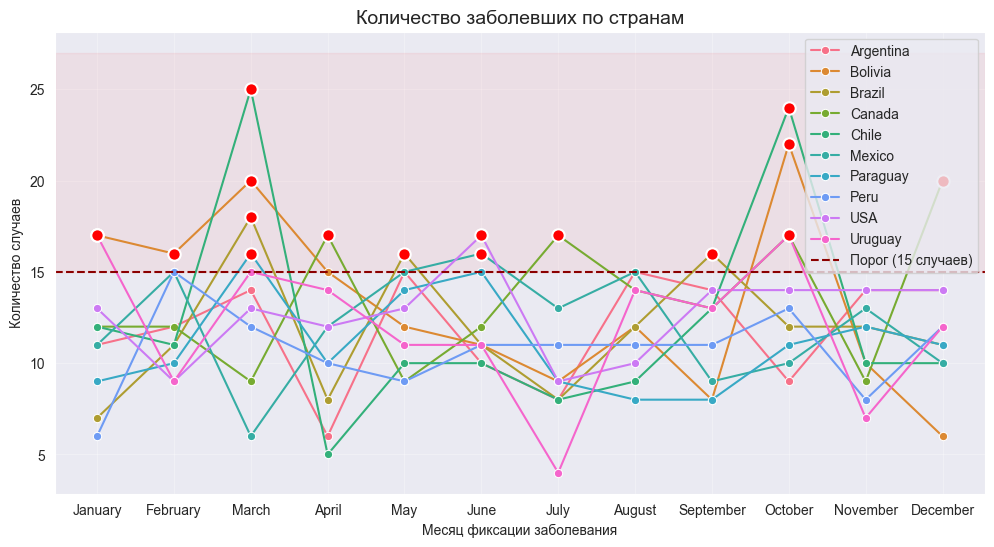

In [151]:
plt.figure(figsize=(12,6))
countries = df[['case_id', 'country', 'report_date','fatality']].copy()
countries['month'] = countries['report_date'].dt.month
countries['year'] = countries['report_date'].dt.year
cases = countries.query('year == 2025').groupby(['month', 'country']).agg(cases=pd.NamedAgg(column='case_id', aggfunc='count'),
                                                                          fatality=pd.NamedAgg(column='fatality', aggfunc='sum')).reset_index()

sns.lineplot(data=cases, x='month', y='cases', hue='country', marker='o')
plt.title('Количество заболевших по странам', fontsize=14)
plt.ylabel('Количество случаев')
plt.xlabel('Месяц фиксации заболевания')
plt.xticks(labels=list(calendar.month_name[1:]), ticks=range(1,13))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Область выше порога
plt.axhspan(ymin=15, ymax=cases['cases'].max()+2, alpha=0.05, color='red')

# Линия порога
plt.axhline(y=15, color='darkred', linestyle='--', linewidth=1.5, label='Порог (15 случаев)')

# Точки превышения
high_points = cases[cases['cases'] > 15]
plt.scatter(high_points['month'], high_points['cases'],
            color='red', s=80, edgecolors='white', linewidth=1.5, zorder=5)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [152]:
cases.sort_values(by='cases', ascending=False)

,month,country,cases,fatality
24,3,Chile,25,3
94,10,Chile,24,5
91,10,Bolivia,22,0
21,3,Bolivia,20,0
113,12,Canada,20,4
...,...,...,...,...
7,1,Peru,6,0
111,12,Bolivia,6,1
30,4,Argentina,6,0
34,4,Chile,5,0


In [153]:
cases_melted = cases.melt(
    id_vars=['country', 'month'],
    value_vars=['cases', 'fatality'],
    var_name='metric',
    value_name='count'
)
cases_melted

,country,month,metric,count
0,Argentina,1,cases,11
1,Bolivia,1,cases,17
2,Brazil,1,cases,7
3,Canada,1,cases,12
4,Chile,1,cases,12
...,...,...,...,...
235,Mexico,12,fatality,0
236,Paraguay,12,fatality,2
237,Peru,12,fatality,0
238,USA,12,fatality,0


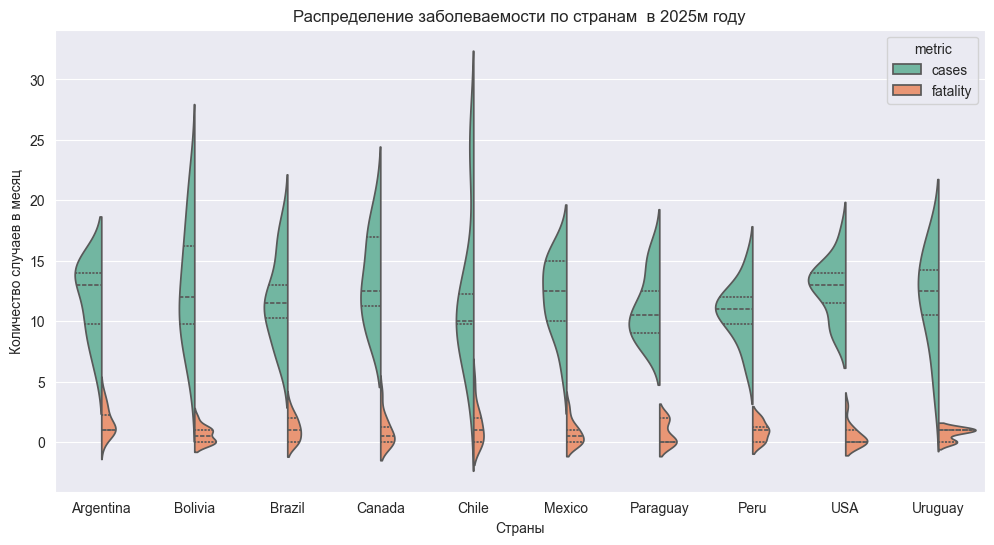

In [154]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cases_melted, x='country', y='count', hue='metric', palette='Set2', split=True, inner='quart')
plt.xlabel('Страны')
plt.ylabel('Количество случаев в месяц')
plt.title('Распределение заболеваемости по странам  в 2025м году')
plt.show()

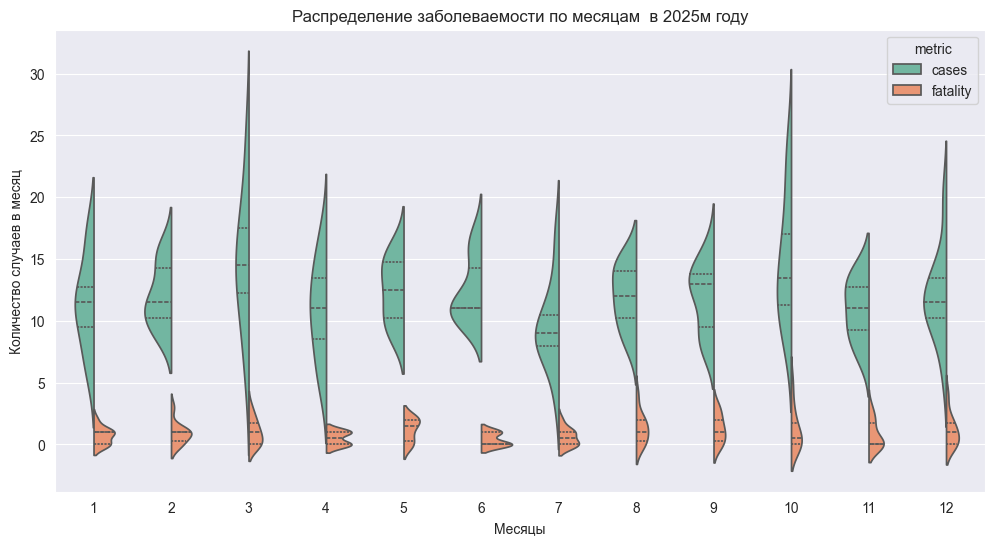

In [155]:
plt.figure(figsize=(12,6))
sns.violinplot(data=cases_melted, x='month', y='count', hue='metric', palette='Set2', split=True, inner='quart')
plt.xlabel('Месяцы')
plt.ylabel('Количество случаев в месяц')
plt.title('Распределение заболеваемости по месяцам  в 2025м году')
plt.show()

In [156]:

plt.figure(figsize=(12,6))
sns.countplot(x='report_month', data=df, hue='year')
plt.xlabel('Месяцы')
plt.ylabel('Количество заболевших по всем странам')
plt.title('Распределение количества заболевших во всех странах по месяцам',fontdict={'fontsize': 14})
plt.show()

ValueError: Could not interpret value `report_month` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

  *Выводы по результатам анализа на сезонность с разбивкой по странам:*
  - СЕЗОННОСТЬ  
     - В 2025м году зафиксировано две вспышки заболеваемости в марте и октябре, но только в двух странах: Чили и Боливия. В остальных странах распределение нормальное, ярко выраженной сезонности не наблюдается.   
     - Данные за неполный 2026 год так же не демонстируют корреляции с сезонностью  

  - ЛОКАЦИЯ  
     - Только в двух странах замечены кратковременные вспышки заболеваемости. На протяжении всего 2025 года эти страны и остальные демонстрируют нормальное распределение, что продолжается в 2026м году.

**Далее рассмотрим, есть ли корреляция между другими признаками и их влияние на целевой признак: заболеваемость и смертность**

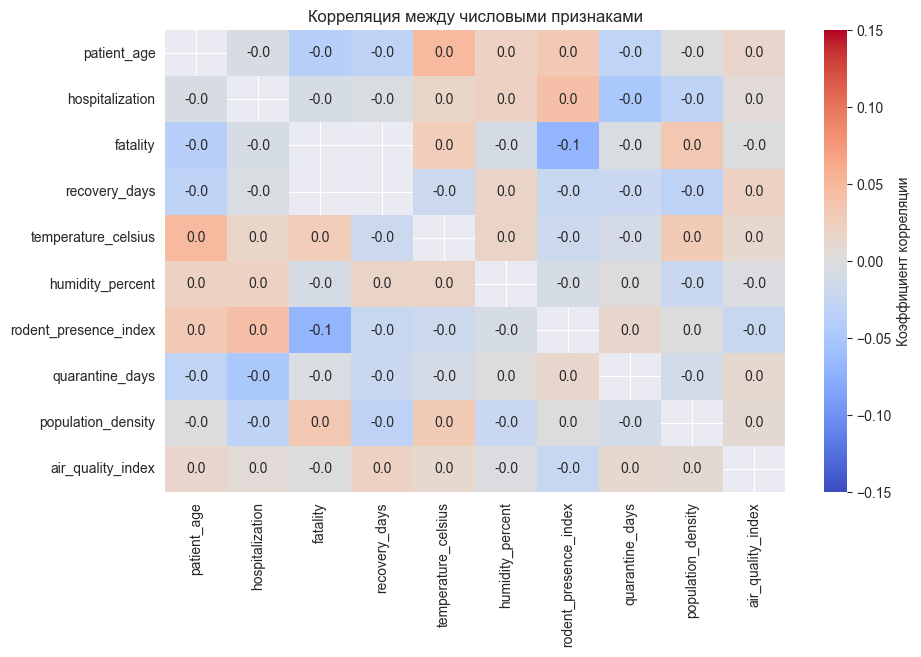

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, center=0, fmt= '.1f', cmap='coolwarm', mask=mask, vmin=-0.15, vmax=0.15,
            cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Корреляция между числовыми признаками');

Сильной корреляции по Пирсону между числовыми признаками не наблюдается. Показатель recovery_days отсутствует для умерших (это 155 человек).

Сформулируем несколько гипотез и проверим их, подсчитав количество заболевших для каждого сценария.

| **Гипотеза**	| **Ожидаемая корреляция**  |
| ----------- | ----------- |
| Чем больше грызунов → тем больше случаев	| Положительная | 
| Высокая влажность → выше выживаемость вируса	| Положительная с cases  |
| Пожилой возраст → выше летальность	| Положительная с fatality  |
| Плотность населения → быстрее распространение	| Положительная с cases  |
| Высокая температура → вирус погибает	| Отрицательная с cases  |


In [ ]:
country_status = (pd.crosstab(
    df['country'],
    df['rodent_presence_index'],
    normalize='index'
)*100).round(2)
country_status = country_status.round(2)
country_status

rodent_presence_index,1,2,3,4,5,6,7,8,9,10
country,,,,,,,,,,
Argentina,11.37,12.32,5.69,10.90,10.90,11.37,9.00,8.53,9.48,10.43
Bolivia,9.30,11.63,12.09,8.37,11.63,14.42,7.91,6.51,7.91,10.23
Brazil,8.21,8.21,9.18,13.04,16.43,10.14,9.18,10.14,7.73,7.73
Canada,8.65,10.10,7.69,9.62,8.17,5.77,11.06,15.38,12.02,11.54
Chile,9.47,11.58,11.05,10.00,8.42,9.47,10.53,10.53,10.00,8.95
Mexico,9.18,10.20,12.24,11.73,6.12,10.20,12.24,6.12,12.24,9.69
Paraguay,10.36,7.25,12.95,10.88,6.22,10.36,9.33,10.36,11.40,10.88
Peru,8.82,10.00,8.24,10.59,10.59,9.41,7.65,14.12,10.59,10.00
USA,9.62,9.62,10.10,11.54,9.13,5.77,16.35,8.17,11.06,8.65


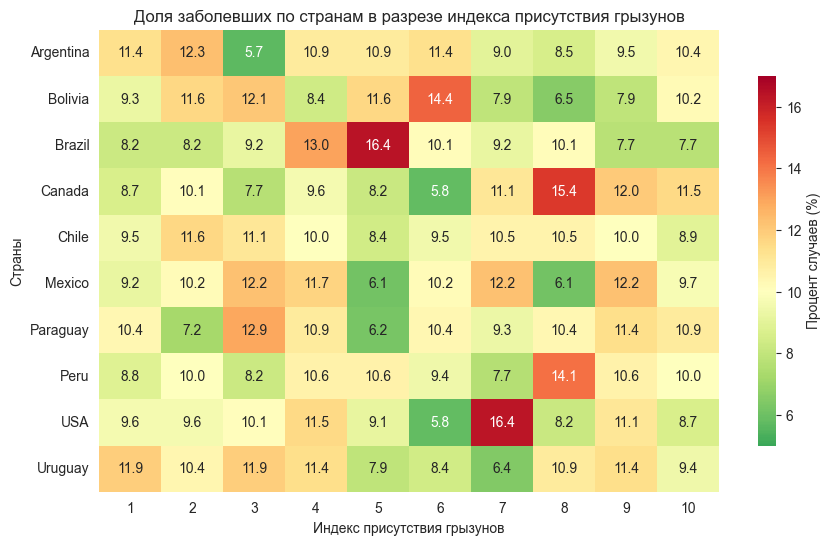

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(country_status, annot=True, fmt='.1f', cmap='RdYlGn_r', center=10, vmin=5, vmax=17, linecolor='white',
            cbar_kws={'label': 'Процент случаев (%)', 'shrink': 0.8})
plt.title('Доля заболевших по странам в разрезе индекса присутствия грызунов')
plt.ylabel('Страны')
plt.xlabel('Индекс присутствия грызунов')

# plt.savefig('../visuals/....png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [ ]:
pd.crosstab(
    [df['transmission_type'],
    df['exposure_source']],
    df['fatality'],
    values=df['case_id'],
    aggfunc='count',
    normalize='index'
)*100

fatality                                         0         1
transmission_type exposure_source                           
Human-to-Human    Agricultural Exposure  92.356688  7.643312
                  Cruise Exposure        93.582888  6.417112
                  Forest Exposure        90.298507  9.701493
                  Home Infestation       92.397661  7.602339
                  Rodent Exposure        92.857143  7.142857
                  Warehouse Exposure     91.919192  8.080808
Rodent-to-Human   Agricultural Exposure  94.039735  5.960265
                  Cruise Exposure        93.413174  6.586826
                  Forest Exposure        91.099476  8.900524
                  Home Infestation       91.875000  8.125000
                  Rodent Exposure        91.758242  8.241758
                  Warehouse Exposure     91.216216  8.783784

на графиках видно, что в зоне с самыми высокими (эпидемичными) уровнями присутствия грызунов самый низкий процент заболеваемости, а остальные типы распределились примерно одинаково, что говорит об отсутствии корреляции между индексом присутствия грызунов и заболеваемостью, что подтверждается статистическим тестом Пирсона

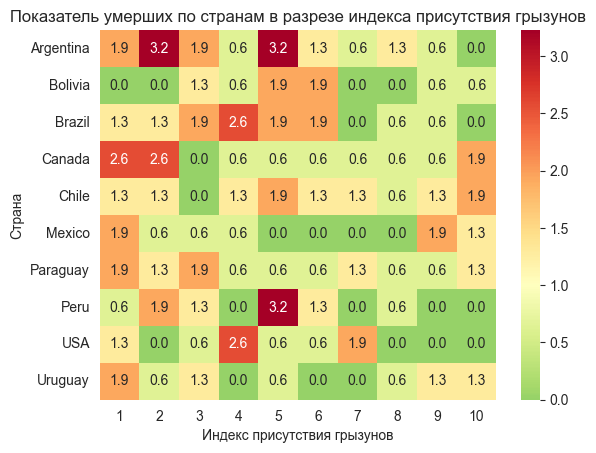

In [ ]:
coutry_fatality = pd.crosstab(columns=df['rodent_presence_index'], index=df['country'],
                              values=df['fatality'], aggfunc='sum', normalize=True)*100
sns.heatmap(coutry_fatality,annot=True, fmt='.1f', cmap='RdYlGn_r', center=1)
plt.title('Показатель умерших по странам в разрезе индекса присутствия грызунов')
plt.xlabel('Индекс присутствия грызунов')
plt.ylabel('Страна');

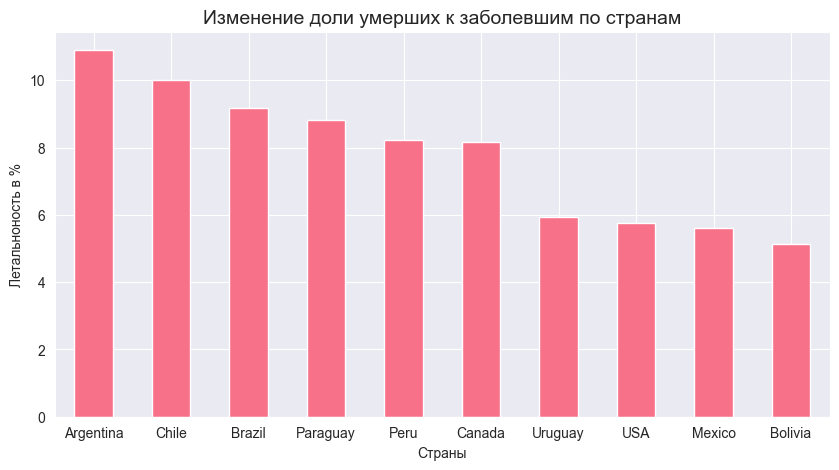

In [ ]:
fatality_rate = (df.groupby('country')['fatality'].mean()*100).round(2).sort_values(ascending=False)
plt.figure(figsize=(10,5))
fatality_rate.plot(kind='bar')
plt.title('Изменение доли умерших к заболевшим по странам', fontsize=14)
plt.ylabel('Летальноность в %')
plt.xlabel('Страны')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# df_2025 = df[df['report_date'].dt.year == 2025].copy()
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
             'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
df['report_month'] = df['report_date'].dt.month.map(lambda x: months[x-1])
df['report_month'] = pd.Categorical(df['report_month'], categories=months, ordered=True)
df['report_month'].unique()

['Ноя', 'Апр', 'Мар', 'Фев', 'Дек', ..., 'Янв', 'Июл', 'Авг', 'Июн', 'Окт']
Length: 12
Categories (12, str): ['Янв' < 'Фев' < 'Мар' < 'Апр' ... 'Сен' < 'Окт' < 'Ноя' < 'Дек']

In [ ]:
df['year'] = df['report_date'].dt.year

In [ ]:
# df['recovery_days'] = pd.qcut(df['recovery_days'], 6)
df['exposure_source'].value_counts(normalize=True) * 100

exposure_source
Cruise Exposure          17.70
Warehouse Exposure       17.30
Rodent Exposure          16.80
Home Infestation         16.55
Forest Exposure          16.25
Agricultural Exposure    15.40
Name: proportion, dtype: float64

In [ ]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index',
       'report_month', 'year'],
      dtype='str')

**Какие симптомы наиболее опасны? (корреляция с летальностью)**

In [ ]:
from copy import deepcopy
df_symptoms = deepcopy(df[['symptoms', 'fatality']])
df_symptoms['symptoms'] = df_symptoms['symptoms'].str.split(', ')
df_symptoms = df_symptoms.explode('symptoms', ignore_index=False)
df_symptoms

,symptoms,fatality
0,Headache,0
0,Vomiting,0
0,Fever,0
1,Fever,0
1,Muscle Pain,0
...,...,...
1998,Shortness of Breath,0
1998,Fever,0
1999,Headache,0
1999,Vomiting,0


In [ ]:
df['symptoms'] = df['symptoms'].str.strip()
symptoms = df_symptoms['symptoms'].unique()
transl = [  'Головная боль',
            'Рвота',
            'Лихорадка',
            'Мышечная боль',
            'Усталость',
            'Кашель',
            'Тошнота',
            'Озноб',
            'Одышка']

In [ ]:
symptoms_ru =dict(zip(symptoms,transl))
print(symptoms_ru)

df_symptoms['symptoms_ru'] = df_symptoms['symptoms'].map(symptoms_ru)
df_symptoms['symptoms_ru']

{'Headache': 'Головная боль', 'Vomiting': 'Рвота', 'Fever': 'Лихорадка', 'Muscle Pain': 'Мышечная боль', 'Fatigue': 'Усталость', 'Cough': 'Кашель', 'Nausea': 'Тошнота', 'Chills': 'Озноб', 'Shortness of Breath': 'Одышка'}


0       Головная боль
0               Рвота
0           Лихорадка
1           Лихорадка
1       Мышечная боль
            ...      
1998           Одышка
1998        Лихорадка
1999    Головная боль
1999            Рвота
1999        Лихорадка
Name: symptoms_ru, Length: 5598, dtype: str

In [ ]:
symptoms_fatality_share = round(df_symptoms.groupby('symptoms_ru')['fatality'].mean().sort_values(ascending=False)*100,2)\
    .reset_index(name='fatality_share')
symptoms_fatality_share

,symptoms_ru,fatality_share
0,Рвота,9.14
1,Головная боль,8.65
2,Мышечная боль,8.64
3,Кашель,8.17
4,Лихорадка,8.10
5,Усталость,7.50
6,Одышка,6.47
7,Озноб,6.33
8,Тошнота,6.33


In [ ]:
# контр проверка и сравнение с симптомами у всех заболевших

contr_group = df_symptoms.groupby('symptoms_ru').agg(
    total=('fatality', 'count'),
    deaths=('fatality', 'sum')
).assign(deaths_share = lambda x: round(x['deaths'] / x['total']*100,2))\
.assign(symptoms_share = lambda x: round(x['total'] / x['total'].sum()*100,2))\
.sort_values('deaths_share', ascending=False)
# order = ['total', 'symptoms_share', 'deaths', 'deaths_share']
contr_group

,total,deaths,deaths_share,symptoms_share
symptoms_ru,,,,
Рвота,394,36,9.14,7.04
Головная боль,798,69,8.65,14.26
Мышечная боль,405,35,8.64,7.23
Кашель,404,33,8.17,7.22
Лихорадка,1605,130,8.10,28.67
Усталость,800,60,7.50,14.29
Одышка,402,26,6.47,7.18
Озноб,395,25,6.33,7.06
Тошнота,395,25,6.33,7.06


In [ ]:
print('Симптомы, встречающиеся наиболее часто:\n')
print(contr_group[['symptoms_share','deaths_share']].sort_values(by='symptoms_share', ascending=False)[:3])
print('\nСимптомы с самым высоким уровнем смертности:\n')
print(contr_group[['symptoms_share','deaths_share']].sort_values(by='deaths_share', ascending=False)[:3])
print('\nСимптомы с самым низким уровнем смертности:\n')
print(contr_group[['symptoms_share','deaths_share']].sort_values(by='deaths_share')[:3])

Симптомы, встречающиеся наиболее часто:

               symptoms_share  deaths_share
symptoms_ru                                
Лихорадка               28.67          8.10
Усталость               14.29          7.50
Головная боль           14.26          8.65

Симптомы с самым высоким уровнем смертности:

               symptoms_share  deaths_share
symptoms_ru                                
Рвота                    7.04          9.14
Головная боль           14.26          8.65
Мышечная боль            7.23          8.64

Симптомы с самым низким уровнем смертности:

             symptoms_share  deaths_share
symptoms_ru                              
Озноб                  7.06          6.33
Тошнота                7.06          6.33
Одышка                 7.18          6.47


**Выводы анализа**  

- Наибольшая летальность ассоциирована с рвотой (9.14%), головной болью (8.65%) и мышечной болью (8.64%). 
- Наиболее частым симптомом является лихорадка (28.7% случаев), однако она не является предиктором повышенной летальности. 
- Озноб и тошнота демонстрируют наименьший процент смертей (6.33%), что может указывать на более легкое течение заболевания при наличии этих симптомов.

**Как зависит тяжесть от типа передачи? (Rodent-to-Human vs другие)**

In [ ]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='str')

In [ ]:
round(df.groupby(['transmission_type', 'exposure_source'])['fatality'].mean()*100,2).sort_values(ascending=False)

transmission_type  exposure_source      
Human-to-Human     Forest Exposure          9.70
Rodent-to-Human    Forest Exposure          8.90
                   Warehouse Exposure       8.78
                   Rodent Exposure          8.24
                   Home Infestation         8.12
Human-to-Human     Warehouse Exposure       8.08
                   Agricultural Exposure    7.64
                   Home Infestation         7.60
                   Rodent Exposure          7.14
Rodent-to-Human    Cruise Exposure          6.59
Human-to-Human     Cruise Exposure          6.42
Rodent-to-Human    Agricultural Exposure    5.96
Name: fatality, dtype: float64

In [ ]:
round(df.groupby(['transmission_type', 'exposure_source'])['recovery_days'].mean(),2).sort_values(ascending=False)


transmission_type  exposure_source      
Rodent-to-Human    Forest Exposure          26.95
Human-to-Human     Home Infestation         26.82
                   Warehouse Exposure       26.81
Rodent-to-Human    Cruise Exposure          26.75
Human-to-Human     Forest Exposure          26.72
Rodent-to-Human    Home Infestation         26.62
Human-to-Human     Cruise Exposure          26.43
                   Agricultural Exposure    26.09
Rodent-to-Human    Agricultural Exposure    26.04
Human-to-Human     Rodent Exposure          25.57
Rodent-to-Human    Warehouse Exposure       25.47
                   Rodent Exposure          25.05
Name: recovery_days, dtype: float64

In [ ]:
round(df.groupby('virus_strain')[['hospitalization','fatality']].mean()*100,2).sort_values(by='hospitalization', ascending=False)

,hospitalization,fatality
virus_strain,,
Seoul,52.66,8.70
Andes,51.78,7.61
Dobrava,50.90,8.53
Sin Nombre,49.65,7.19
Puumala,46.52,6.68


In [ ]:
round(df.groupby('virus_strain')['recovery_days'].mean(),2).sort_values(ascending=False)

virus_strain
Puumala       26.99
Dobrava       26.67
Andes         26.46
Sin Nombre    26.00
Seoul         25.44
Name: recovery_days, dtype: float64

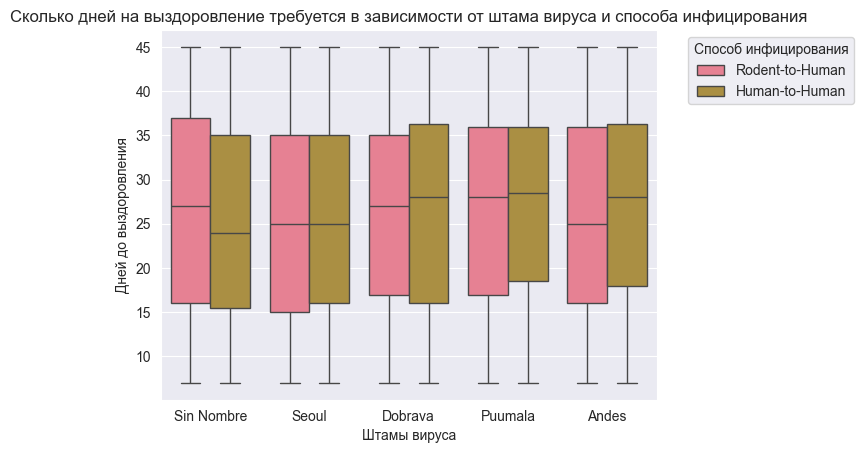

In [ ]:
plt.Figure(figsize=(12,6))
sns.boxplot(df, x='virus_strain', y='recovery_days', hue='transmission_type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Способ инфицирования')
plt.xlabel('Штамы вируса')
plt.ylabel('Дней до выздоровления')
plt.title('Сколько дней на выздоровление требуется в зависимости от штама вируса и способа инфицирования')
plt.show()

In [ ]:
df_corr = round(df.groupby(['transmission_type', 'exposure_source', 'virus_strain'])[['hospitalization','fatality']]\
      .mean()*100,2).sort_values(by='hospitalization', ascending=False)

In [ ]:
print('Комбинация признаков с самой высокой госпитализацией и смертностью:')
high_risk = df_corr[(df_corr['hospitalization'] > 50)&(df_corr['fatality'] > 10)]
print(high_risk)

Комбинация признаков с самой высокой госпитализацией и смертностью:
                                                      hospitalization  \
transmission_type exposure_source       virus_strain                    
Rodent-to-Human   Forest Exposure       Seoul                   65.79   
Human-to-Human    Warehouse Exposure    Seoul                   63.41   
Rodent-to-Human   Agricultural Exposure Seoul                   55.56   
                  Warehouse Exposure    Dobrava                 54.84   
Human-to-Human    Home Infestation      Andes                   54.05   
                  Forest Exposure       Sin Nombre              51.61   

                                                      fatality  
transmission_type exposure_source       virus_strain            
Rodent-to-Human   Forest Exposure       Seoul            13.16  
Human-to-Human    Warehouse Exposure    Seoul            12.20  
Rodent-to-Human   Agricultural Exposure Seoul            11.11  
                  Ware

In [ ]:
df['hospitalization'].corr(df['fatality'])

np.float64(-0.007639037940243435)

In [ ]:
# 1. Стратификация по возрасту
age_groups = pd.cut(df['patient_age'], bins=[0, 30, 50, 70, 100], labels=['<30', '30-50', '50-70', '>70'])
for age in age_groups.unique():
    subset = df[age_groups == age]
    corr = subset['hospitalization'].corr(subset['fatality'])
    print(f"Возраст {age}: корреляция = {corr:.4f}")

# 2. Стратификация по штамму
for strain in df['virus_strain'].unique():
    subset = df[df['virus_strain'] == strain]
    corr = subset['hospitalization'].corr(subset['fatality'])
    print(f"Штамм {strain}: корреляция = {corr:.4f}")

# 3. Логистическая регрессия

X = df[['hospitalization']].fillna(0)
y = df['fatality']

model = LogisticRegression()
model.fit(X, y)
print(f"Коэффициент логистической регрессии: {model.coef_[0][0]:.4f}")

Возраст <30: корреляция = 0.0256
Возраст 30-50: корреляция = -0.0537
Возраст 50-70: корреляция = 0.0106
Возраст >70: корреляция = 0.0021
Штамм Sin Nombre: корреляция = -0.0789
Штамм Seoul: корреляция = -0.0164
Штамм Dobrava: корреляция = -0.0148
Штамм Puumala: корреляция = 0.0508
Штамм Andes: корреляция = 0.0281
Коэффициент логистической регрессии: -0.0575


In [ ]:
print(f"Всего госпитализировано: {df['hospitalization'].sum()} из {len(df)} ({df['hospitalization'].mean()*100:.1f}%)")
print(f"Всего умерло: {df['fatality'].sum()} из {len(df)} ({df['fatality'].mean()*100:.1f}%)")

ct = pd.crosstab(df['hospitalization'], df['fatality'], normalize='all') * 100
print(ct)

# Если госпитализация близка к 100% → корреляция будет стремиться к нулю
# Если смертность близка к 0% → корреляция будет стремиться к нулю

Всего госпитализировано: 1007 из 2000 (50.3%)
Всего умерло: 155 из 2000 (7.8%)
fatality             0     1
hospitalization             
0                45.70  3.95
1                46.55  3.80


**Госпитализация НЕ влияет на летальность при хантавирусе в данном датасете.**

ДАННЫЕ ПОДТВЕРЖДАЮТ:
- Летальность без госпитализации: 7.96%
- Летальность с госпитализацией: 7.55%
- Разница статистически незначима

ВОЗМОЖНЫЕ ПРИЧИНЫ:
1. Госпитализируют пациентов любой степени тяжести (нет триажа)
2. Лечение в стационаре не влияет на исход (нет эффективной терапии?)
3. Критические пациенты умирают до госпитализации

КЛИНИЧЕСКАЯ ЗНАЧИМОСТЬ:
- Госпитализация сама по себе не является протективным фактором
- Необходимы другие меры для снижения летальности (ранняя диагностика, специфическое лечение)

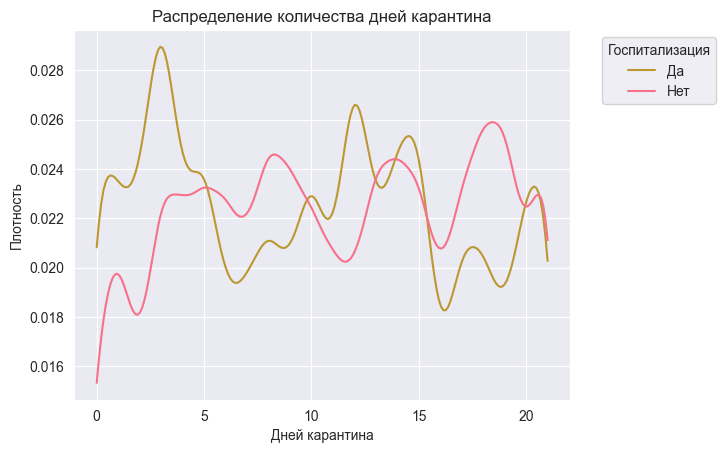

In [184]:
sns.kdeplot(data=df,x='quarantine_days',
            hue='hospitalization',
            bw_method=0.1,
            clip=(df['quarantine_days'].min(),df['quarantine_days'].max()))
plt.title('Распределение количества дней карантина')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Госпитализация', labels=['Да', 'Нет'])
plt.xlabel('Дней карантина')
plt.ylabel('Плотность')
plt.show()

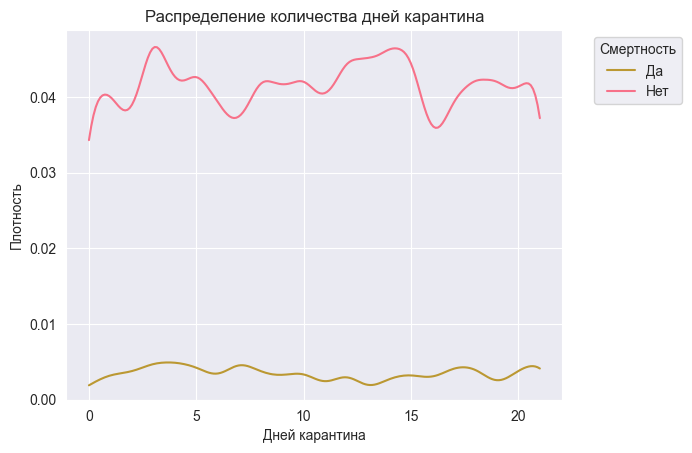

In [190]:
sns.kdeplot(data=df,x='quarantine_days',
            hue='fatality',
            bw_method=0.1,
            clip=(df['quarantine_days'].min(),df['quarantine_days'].max()))
plt.title('Распределение количества дней карантина')

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Смертность', labels=['Да', 'Нет'])
plt.xlabel('Дней карантина')
plt.ylabel('Плотность')
plt.show()

In [185]:
pd.crosstab(df['fatality'], df['hospitalization'], values=df['quarantine_days'], aggfunc='mean')

hospitalization,0,1
fatality,,
0,10.866521,10.258861
1,10.873418,10.013158


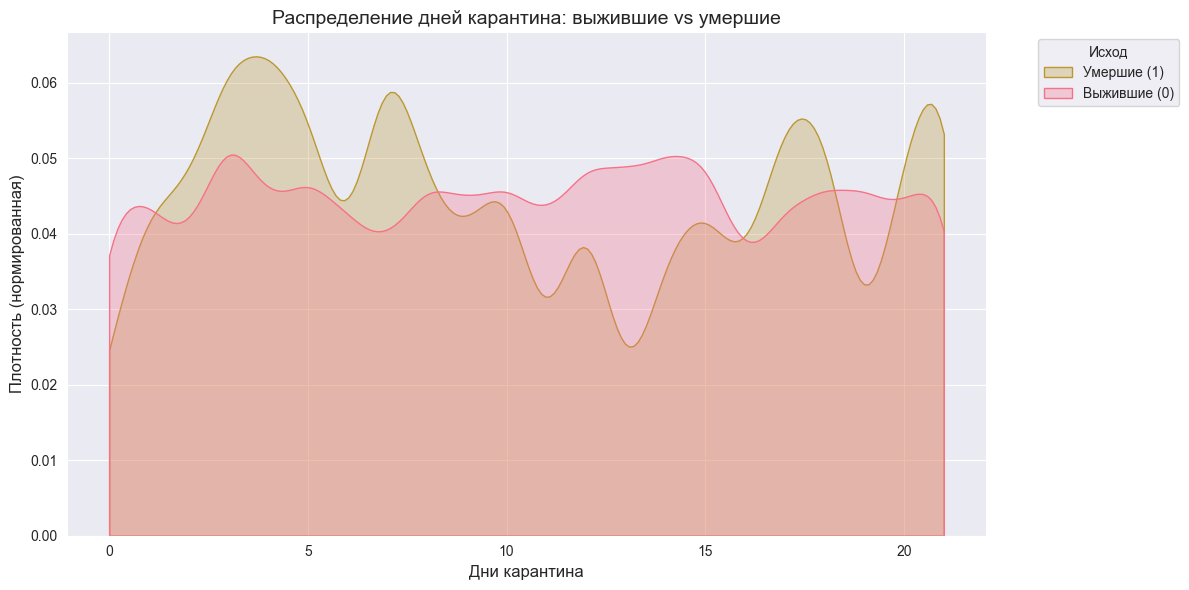

In [206]:
plt.figure(figsize=(12, 6))

# Правильное построение
sns.kdeplot(data=df, x='quarantine_days',
            hue='fatality',
            bw_method=0.1,
            clip=(df['quarantine_days'].min(), df['quarantine_days'].max()),
            fill=True,  # Добавляем заливку для наглядности
            alpha=0.3,
            common_norm=False)  # Нормируем каждую группу отдельно

plt.title('Распределение дней карантина: выжившие vs умершие', fontsize=14)
plt.xlabel('Дни карантина', fontsize=12)
plt.ylabel('Плотность (нормированная)', fontsize=12)

# Правильная легенда
plt.legend(title='Исход',
           labels=['Умершие (1)','Выжившие (0)'],
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

plt.tight_layout()
plt.show()

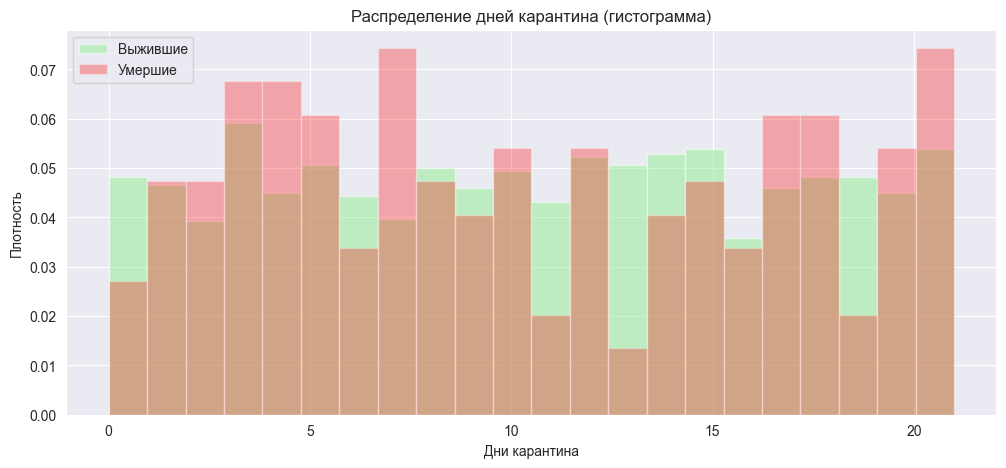

In [217]:
survived = df[df['fatality'] == 0]['quarantine_days'].dropna()
died = df[df['fatality'] == 1]['quarantine_days'].dropna()

bins=df['quarantine_days'].nunique()
# Гистограмма покажет точные пики
plt.figure(figsize=(12, 5))
plt.hist(survived, bins=bins, alpha=0.5, label='Выжившие', density=True, color='lightgreen')
plt.hist(died, bins=bins, alpha=0.3, label='Умершие', density=True, color='red')
plt.xlabel('Дни карантина')
plt.ylabel('Плотность')
plt.title('Распределение дней карантина (гистограмма)')
plt.legend()
plt.show()


In [221]:

survived_hist, bins = np.histogram(survived, bins=bins)
peak_bins = bins[:-1][survived_hist > survived_hist.mean() + survived_hist.std()]
print(f"Пики у выживших: {peak_bins}")

Пики у выживших: [ 2.86363636 14.31818182 20.04545455]


In [223]:

died_hist, bins = np.histogram(died, bins=bins)
peak_bins = bins[:-1][died_hist > died_hist.mean() + died_hist.std()]
print(f"Пики у умерших: {peak_bins}")

Пики у умерших: [ 2.86363636  3.81818182  6.68181818 20.04545455]


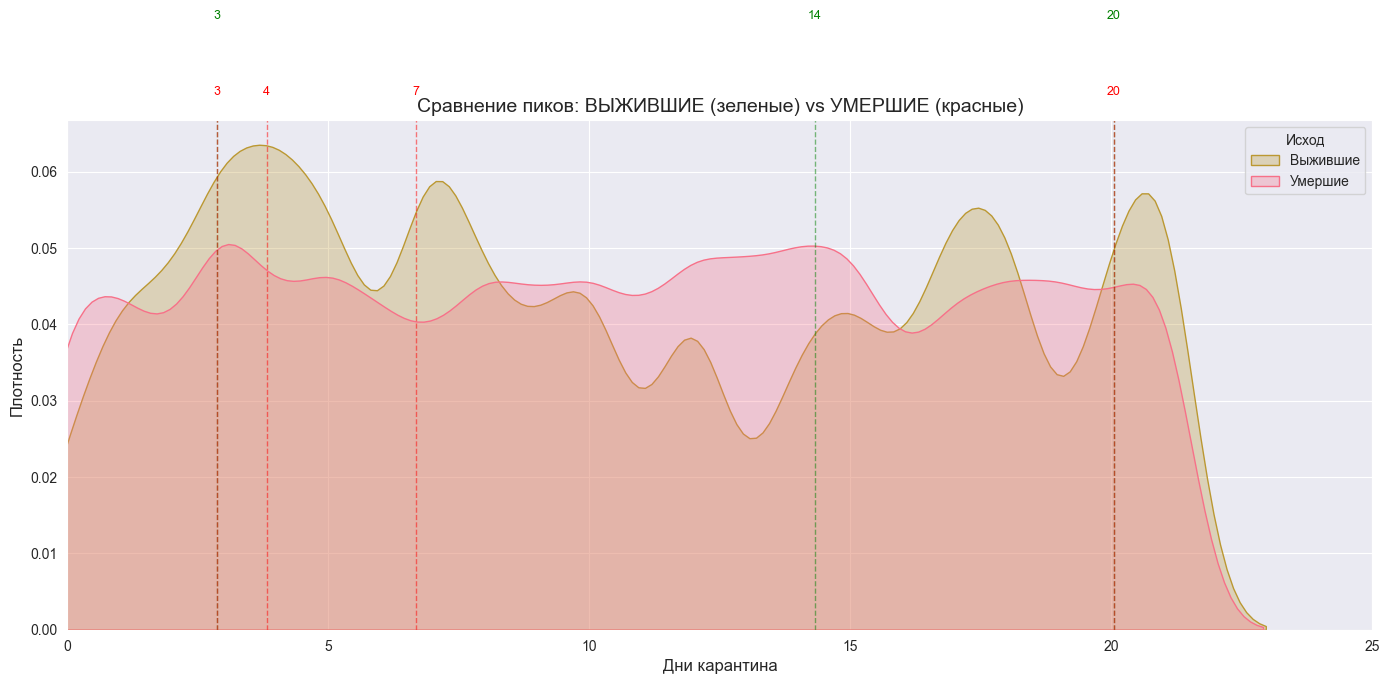

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 7))

# KDE график
sns.kdeplot(data=df, x='quarantine_days', hue='fatality',
            bw_method=0.1, common_norm=False, fill=True, alpha=0.3)

# Пики выживших (зеленые)
survived_peaks = [2.86, 14.32, 20.05]
for peak in survived_peaks:
    plt.axvline(x=peak, color='green', linestyle='--', alpha=0.5, linewidth=1)
    plt.text(peak, 0.08, f'{peak:.0f}', ha='center', fontsize=9, color='green')

# Пики умерших (красные)
died_peaks = [2.86, 3.82, 6.68, 20.05]
for peak in died_peaks:
    plt.axvline(x=peak, color='red', linestyle='--', alpha=0.5, linewidth=1)
    plt.text(peak, 0.07, f'{peak:.0f}', ha='center', fontsize=9, color='red')

plt.title('Сравнение пиков: ВЫЖИВШИЕ (зеленые) vs УМЕРШИЕ (красные)', fontsize=14)
plt.xlabel('Дни карантина', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(title='Исход', labels=['Выжившие', 'Умершие'])
plt.xlim(0, 25)
plt.tight_layout()
plt.show()